# Rack Power Prediction — Playground

Every heavy operation lives in the `rack_forecast` package; this notebook wires the
steps together so each one stays runnable and inspectable.

- **Explore step by step** (sections 1-8): build data → split/scale → window → train → evaluate → plot → save.
- **One-liner** (section 9): `run_experiment(cfg)` does all of the above in a single call (used by the CLI script and dashboard).

## 1. Config

In [1]:
from rack_forecast import ExperimentConfig

cfg = ExperimentConfig(
    target_rack='R0605-PA',
    lookback=20,          # past steps of context (1 step = 30 s)
    horizon=60,           # steps predicted per window (60 = 30 min)
    models=['linear', 'rf', 'xgboost', 'lstm', 'cnn1d', 'transformer'],
    dl_epochs=30,
    fast_mode=True,       # target rack only (no SensorGW features)
    train_days=7,         # None = full 5 months; N = first N days
    predict_days=1,       # None = full test month; N = first N days
    run_id='run_nb_01',
)
print('Run folder →', cfg.run_folder)

Run folder → D:\Research\Proposal\BESS\code\NTU\results\run_nb_01_R0605-PA_L20_H60


In [2]:
# GPU check (DL models + xgboost use it; linear/rf run on CPU)
import torch
print('CUDA:', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

CUDA: True | NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Build dataset

In [3]:
from rack_forecast.data import build_dataset

data = build_dataset(cfg)
print(f'{data.shape}  |  {data.index.min()} → {data.index.max()}')
data.head(3)

(521246, 17)  |  2022-09-01 00:00:00 → 2023-02-28 23:59:30


,R0605-PA__kW,R0605-PA__V,R0605-PA__A,R0605-PA__PF,R0605-PA__Hz,THFT__temp_C,THFT__humidity_pct,THFM__temp_C,THFM__humidity_pct,THFB__temp_C,THFB__humidity_pct,THBB__temp_C,THBB__humidity_pct,THBM__temp_C,THBM__humidity_pct,THBT__temp_C,THBT__humidity_pct
timestamp,,,,,,,,,,,,,,,,,
2022-09-01 00:00:00,0.563,229.4,2.79,0.88,659.8,33.3,44.0,33.3,46.0,33.9,43.0,38.1,35.0,34.6,42.0,36.9,38.0
2022-09-01 00:00:30,0.514,229.1,2.57,0.87,659.8,33.3,44.0,33.3,46.0,33.8,43.0,38.1,35.0,34.6,42.0,37.0,38.0
2022-09-01 00:01:00,0.535,229.7,2.66,0.88,659.8,33.3,44.0,33.3,46.0,33.8,43.0,38.1,35.0,34.6,42.0,37.0,37.0


## 3. Split & scale

In [4]:
from rack_forecast.pipeline import prepare_data

prep = prepare_data(data, cfg)
print(f'Train: {len(prep.X_train):,}   Test: {len(prep.X_test):,}   Features: {prep.n_feat}')
print(f'Train months: {prep.months[0]} → {prep.months[-2]}   |   Test month: {prep.months[-1]}')

Train: 20,160   Test: 2,880   Features: 17
Train months: 2022-09 → 2023-01   |   Test month: 2023-02


## 4. Window

In [5]:
from rack_forecast.windowing import make_supervised

X_3d, y_sup = make_supervised(prep.X_train, prep.y_train, cfg.lookback)
print('X_3d:', X_3d.shape, '  y_sup:', y_sup.shape)

X_3d: (20140, 20, 17)   y_sup: (20140, 17)


## 5. Train each model

In [6]:
import time
from rack_forecast.trainer import build_and_train

trained, train_log = {}, {}
for name in cfg.models:
    t0 = time.time()
    print(f'[{name}] training...')
    trained[name] = build_and_train(name, X_3d, y_sup, cfg.lookback, prep.n_feat,
                                    dl_epochs=cfg.dl_epochs)
    train_log[name] = time.time() - t0
    print(f'  done ({train_log[name]:.1f}s)')

[rack_forecast] device: cuda
[linear] training...
    backend: sklearn
  done (0.1s)
[rf] training...
    backend: sklearn


  done (64.9s)
[xgboost] training...
    backend: cuda


  done (22.8s)
[lstm] training...


  epochs:   0%|          | 0/30 [00:00<?, ?ep/s]

  epochs:   0%|          | 0/30 [00:01<?, ?ep/s, best=inf, val_loss=0.37980]

...

  epochs:  57%|█████▋    | 17/30 [00:28<00:20,  1.57s/ep, best=0.16302, val_loss=0.16403]

  epochs:  60%|██████    | 18/30 [00:28<00:18,  1.56s/ep, best=0.16302, val_loss=0.16403]

  epochs:  60%|██████    | 18/30 [00:30<00:18,  1.56s/ep, best=0.16302, val_loss=0.17240]

  epochs:  60%|██████    | 18/30 [00:30<00:18,  1.56s/ep, best=0.16302, val_loss=0.17240]

    early stop at epoch 19  val_loss=0.17240
  done (30.2s)


## 6. Evaluate (autoregressive rollout)

In [7]:
from rack_forecast.evaluate import evaluate, compute_metrics

results = {}
for name, model in trained.items():
    preds, actuals = evaluate(model, prep.X_test, prep.y_test,
                              cfg.lookback, cfg.horizon, prep.target_idx,
                              prep.scaler, prep.n_feat)
    m = compute_metrics(actuals, preds)
    m['train_time_s'] = round(train_log[name], 1)
    results[name] = {'preds': preds, 'actuals': actuals, 'metrics': m}
    print(f'  {name:12s}  MAE={m["MAE"]:.4f}  RMSE={m["RMSE"]:.4f}  R2={m["R2"]:.4f}')

  steps:   0%|          | 0/60 [00:00<?, ?step/s]

  linear        MAE=0.3275  RMSE=0.3380  R2=-344.1087


  steps:   0%|          | 0/60 [00:00<?, ?step/s]

  steps:   3%|▎         | 2/60 [00:00<00:03, 14.66step/s]

  steps:   7%|▋         | 4/60 [00:00<00:03, 15.65step/s]

...

  steps:   0%|          | 0/60 [00:00<?, ?step/s]

  steps:  23%|██▎       | 14/60 [00:00<00:00, 139.98step/s]

  steps:  57%|█████▋    | 34/60 [00:00<00:00, 173.19step/s]

  steps:  90%|█████████ | 54/60 [00:00<00:00, 183.89step/s]

  transformer   MAE=0.0287  RMSE=0.0342  R2=-2.5358


## 7. Metrics table & plots

In [8]:
import pandas as pd
metrics_df = pd.DataFrame({n: r['metrics'] for n, r in results.items()}).T.round(4)
metrics_df.sort_values('RMSE')

,MAE,RMSE,MAPE(%),R2,train_time_s
xgboost,0.0121,0.0156,2.4909,0.2630,22.8
rf,0.0140,0.0179,2.9323,0.0295,64.9
transformer,0.0287,0.0342,5.8684,-2.5358,30.2
lstm,0.0316,0.0397,6.4674,-3.7616,23.0
linear,0.3275,0.3380,68.6203,-344.1087,0.1
cnn1d,0.4770,0.4806,99.7196,-696.4782,13.3


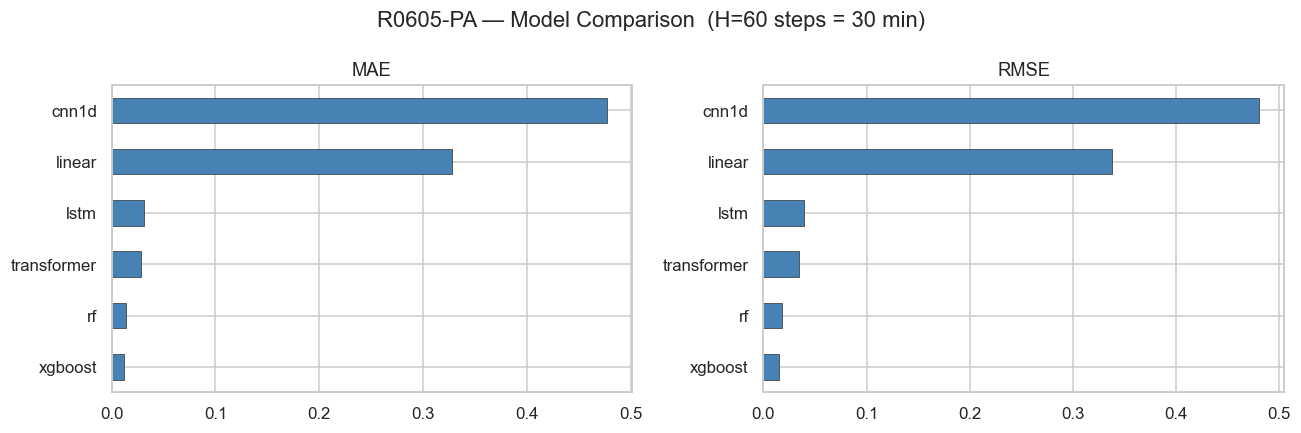

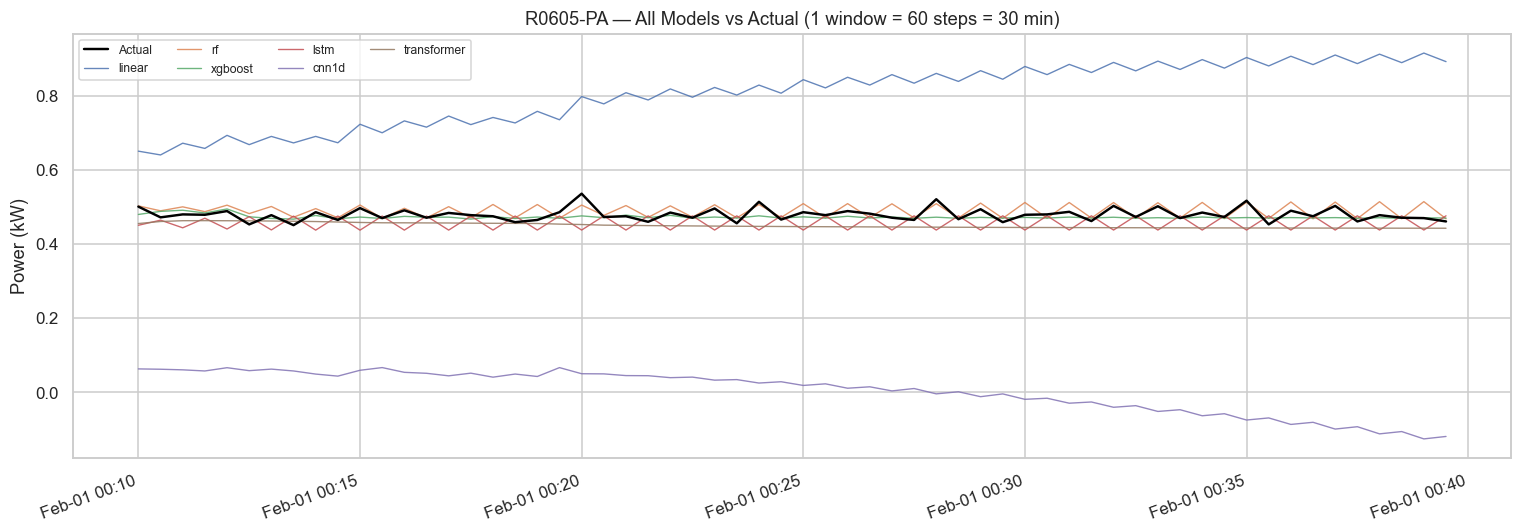

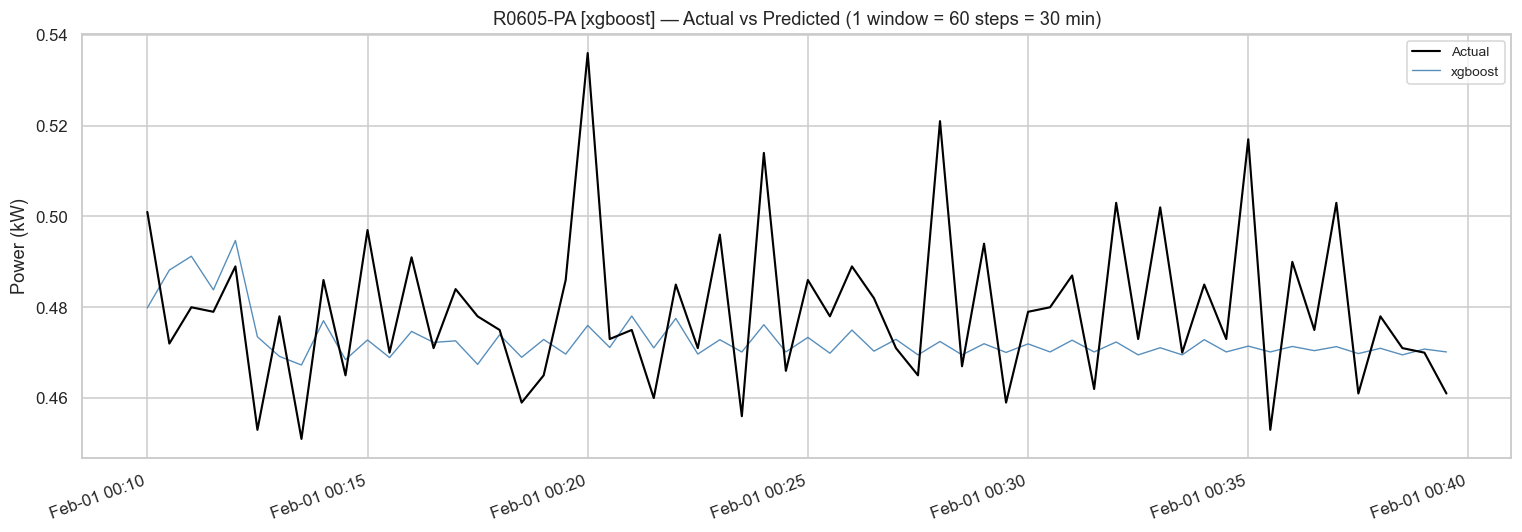

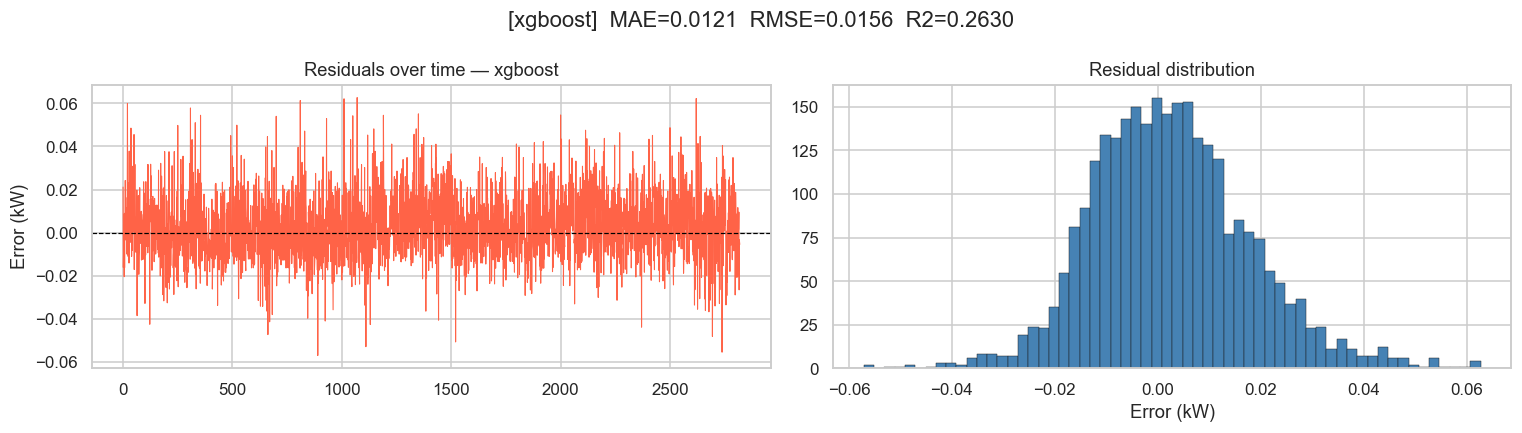

In [9]:
from rack_forecast import plots

plots.plot_metrics_bar(metrics_df, cfg)
plots.plot_all_models_vs_actual(results, prep.test_df.index, cfg)
best = metrics_df['RMSE'].idxmin()
plots.plot_actual_vs_pred(best, results, prep.test_df.index, cfg)
plots.plot_residuals(best, results);

## 8. Save everything (config, metrics, scalers, models, predictions, figures)

In [10]:
from rack_forecast.pipeline import save_results

save_results(cfg, prep, trained, results, metrics_df)
print('Saved →', cfg.run_folder)

Saved → D:\Research\Proposal\BESS\code\NTU\results\run_nb_01_R0605-PA_L20_H60


## 9. One-liner shortcut

The whole of sections 2-8 in a single call — this is exactly what the CLI script and
dashboard use. Uncomment to run.

In [11]:
# from rack_forecast.pipeline import run_experiment
# results, metrics_df, prep = run_experiment(cfg)